In [8]:
import os
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd
from google.cloud import bigquery

In [9]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/workspaces/codespaces-blank/dags/gcp-key.json"

In [10]:
client = bigquery.Client()

In [11]:
query = """
select
  round(avg(house_price + house_fee), 2) as avg_price,

  split(replace(formatted_address, ',', ' '), ' ')[OFFSET(0)] as city

from `japan-house-data.housing_raw_data.silver_house`
where NOT (house_price=0 AND house_fee=0)
group by city
order by avg_price DESC
LIMIT 10
"""

In [12]:
sb.set_theme(style="whitegrid")

In [13]:
df = client.query(query).to_dataframe()

print(df.columns)
print(df.head())

Index(['avg_price', 'city'], dtype='object')
   avg_price        city
0   87216.67    Roppongi
1   86916.67  Nakameguro
2   82400.00   Kichijoji
3   80437.50     Shibuya
4   74600.00     Chitose


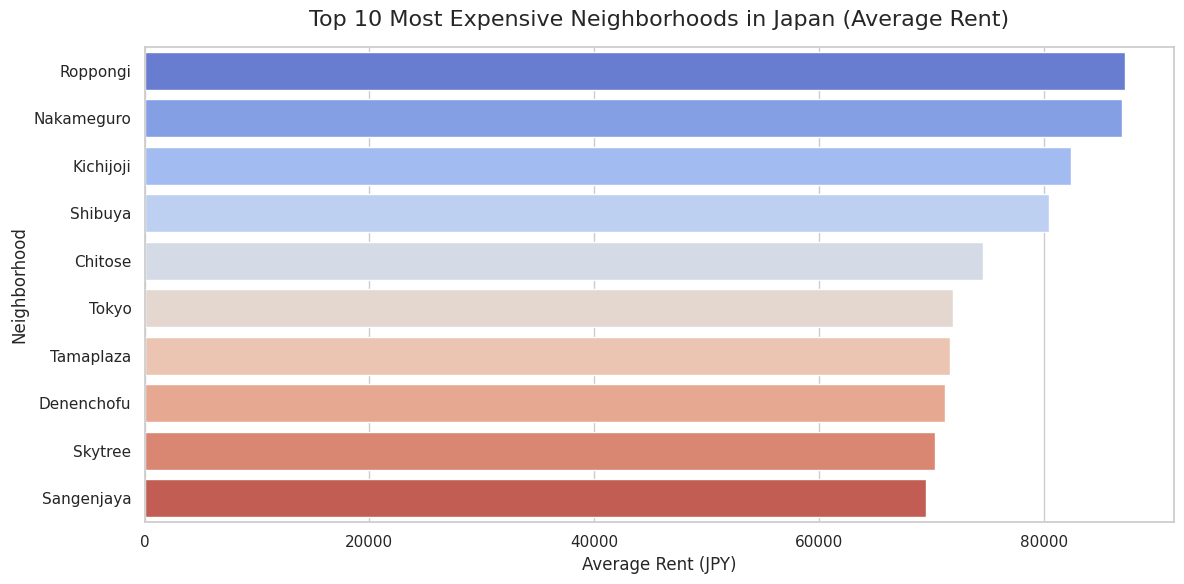

In [15]:
plt.figure(figsize=(12, 6))

ax = sb.barplot(x="avg_price", y="city", data=df, hue="city", palette="coolwarm", legend=False)

plt.title("Top 10 Most Expensive Neighborhoods in Japan (Average Rent)", fontsize=16, pad=15)
plt.xlabel("Average Rent (JPY)", fontsize=12)
plt.ylabel("Neighborhood", fontsize=12)

plt.tight_layout()
plt.savefig("tokyo_rent_analysis.png", dpi=300)
plt.show()